# DataVine Analytics — Summative Lab
### Wine Classification • Chickwts Recommendation • USArrests Clustering



This notebook implements three prototype ML solutions for DataVine Analytics' clients, covering the full workflow — EDA, preprocessing, dimensionality reduction, model implementation, hyperparameter tuning, and evaluation:

1. **Wine Classification System** — k-NN with PCA + GridSearchCV
2. **Agricultural Feed Recommendation Engine** — PCA + Cosine Similarity
3. **Regional Crime Pattern Analysis** — K-Means & GMM Clustering


### problem statement

- Wine data: Predicts which of 3 grape types a wine came from, based on its chemistry.
- Chick feed data: Compares 6 chicken feed types to see which ones give similar weight gain, so a farmer could swap one for another.
- US crime data:Groups US states by crime patterns to spot regions with similar issues.


In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
print("Libraries loaded successfully.")


Libraries loaded successfully.


---
## 1. Dataset Preparation

We load all three datasets, inspect their structure, check for missing values / inconsistencies, and standardize numerical features where required.


### 1.1 Wine Dataset

In [2]:
wine = pd.read_csv("wine.csv")
print("Shape:", wine.shape)
wine.info()
wine.head()


Shape: (178, 14)
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
print("Missing values per column:\n", wine.isnull().sum())
print("\nDuplicate rows:", wine.duplicated().sum())
wine.describe().T


Missing values per column:
 Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Wine,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


**Observation:** The Wine dataset has 178 samples, 13 numeric chemical-analysis features, and a `Wine` column (values 1, 2, 3) representing the cultivar/class. No missing values or duplicates are present. Feature scales vary widely (e.g. `Proline` in the hundreds vs `Hue` under 2), so standardization is required before PCA/k-NN.

### 1.2 Chickwts Dataset

In [4]:
chickwts = pd.read_csv("chickwts.csv")
print("Shape:", chickwts.shape)
chickwts.info()
chickwts.head()


Shape: (71, 3)
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   rownames  71 non-null     int64
 1   weight    71 non-null     int64
 2   feed      71 non-null     str  
dtypes: int64(2), str(1)
memory usage: 1.8 KB


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [5]:
print("Missing values per column:\n", chickwts.isnull().sum())
print("\nDuplicate rows:", chickwts.duplicated().sum())
print("\nFeed types:\n", chickwts['feed'].value_counts())
chickwts.describe()


Missing values per column:
 rownames    0
weight      0
feed        0
dtype: int64

Duplicate rows: 0

Feed types:
 feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64


,rownames,weight
count,71.000000,71.000000
mean,36.000000,261.309859
std,20.639767,78.073700
min,1.000000,108.000000
25%,18.500000,204.500000
50%,36.000000,258.000000
75%,53.500000,323.500000
max,71.000000,423.000000


**Observation:** 71 chicks, each with a `weight` (grams) after being fed one of six `feed` types. No missing values. This is small tabular data suited to a feed-similarity/recommendation approach based on average weight outcomes.

### 1.3 USArrests Dataset

In [6]:
usarrests = pd.read_csv("USArrests.csv")
print("Shape:", usarrests.shape)
usarrests.info()
usarrests.head()


Shape: (50, 5)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
 4   State     50 non-null     str    
dtypes: float64(2), int64(2), str(1)
memory usage: 2.1 KB


,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


In [7]:
print("Missing values per column:\n", usarrests.isnull().sum())
print("\nDuplicate rows:", usarrests.duplicated().sum())
usarrests.describe().T


Missing values per column:
 Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


**Observation:** 50 US states with 4 numeric crime/urbanization features (`Murder`, `Assault`, `UrbanPop`, `Rape`) and a `State` identifier. No missing values. `Assault` is on a much larger scale than the others, so standardization is essential before clustering.

### 1.4 Dataset Structure Summary

In [8]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Wine", "Chickwts", "USArrests"],
    "Rows": [wine.shape[0], chickwts.shape[0], usarrests.shape[0]],
    "Columns": [wine.shape[1], chickwts.shape[1], usarrests.shape[1]],
    "Missing Values": [wine.isnull().sum().sum(), chickwts.isnull().sum().sum(), usarrests.isnull().sum().sum()],
    "Target/Key Variable": ["Wine (cultivar class)", "feed (categorical)", "State (identifier)"]
})
dataset_summary


,Dataset,Rows,Columns,Missing Values,Target/Key Variable
0,Wine,178,14,0,Wine (cultivar class)
1,Chickwts,71,3,0,feed (categorical)
2,USArrests,50,5,0,State (identifier)


### 1.5 Standardize Numerical Features

In [9]:
# Wine: standardize all 13 chemical features (exclude target 'Wine')
wine_features = wine.drop(columns=['Wine'])
wine_target = wine['Wine']

scaler_wine = StandardScaler()
wine_scaled = pd.DataFrame(scaler_wine.fit_transform(wine_features), columns=wine_features.columns)

# Chickwts: standardize weight
scaler_chick = StandardScaler()
chickwts['weight_scaled'] = scaler_chick.fit_transform(chickwts[['weight']])

# USArrests: standardize the 4 numeric features (State is an identifier, not a feature)
usarrests_features = usarrests.drop(columns=['State'])
scaler_us = StandardScaler()
usarrests_scaled = pd.DataFrame(scaler_us.fit_transform(usarrests_features), columns=usarrests_features.columns)

print("Wine (scaled) preview:")
display(wine_scaled.head())
print("\nChickwts (scaled) preview:")
display(chickwts.head())
print("\nUSArrests (scaled) preview:")
display(usarrests_scaled.head())


Wine (scaled) preview:

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874



Chickwts (scaled) preview:


,rownames,weight,feed,weight_scaled
0,1,179,horsebean,-1.061762
1,2,160,horsebean,-1.306854
2,3,136,horsebean,-1.616444
3,4,227,horsebean,-0.442583
4,5,217,horsebean,-0.571578



USArrests (scaled) preview:


,Murder,Assault,UrbanPop,Rape
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


---
## 2. k-NN Classification System — Wine Dataset

**Goal:** Classify wines into their cultivar class (1, 2, or 3) using PCA-reduced features and a hyperparameter-tuned k-NN classifier.


### 2.1 Encode Target Labels

Although the `Wine` target is already represented numerically (1, 2, 3), `LabelEncoder` is applied here to explicitly satisfy the label-encoding requirement, guarantee zero-indexed contiguous class labels (0, 1, 2), and ensure the target is in the exact format expected by scikit-learn's classification workflow.

In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(wine_target)
print("Original classes:", sorted(wine_target.unique()))
print("Encoded classes:", sorted(set(y_encoded)))
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Original classes: [np.int64(1), np.int64(2), np.int64(3)]
Encoded classes: [np.int64(0), np.int64(1), np.int64(2)]
Class mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}


### 2.2 PCA — Retain 95% Variance

In [11]:
pca_wine = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_wine_pca = pca_wine.fit_transform(wine_scaled)

print(f"Number of components retained for 95% variance: {pca_wine.n_components_}")
print(f"Explained variance ratio per component: {np.round(pca_wine.explained_variance_ratio_, 3)}")
print(f"Cumulative explained variance: {pca_wine.explained_variance_ratio_.sum():.3f}")


Number of components retained for 95% variance: 10
Explained variance ratio per component: [0.362 0.192 0.111 0.071 0.066 0.049 0.042 0.027 0.022 0.019]
Cumulative explained variance: 0.962


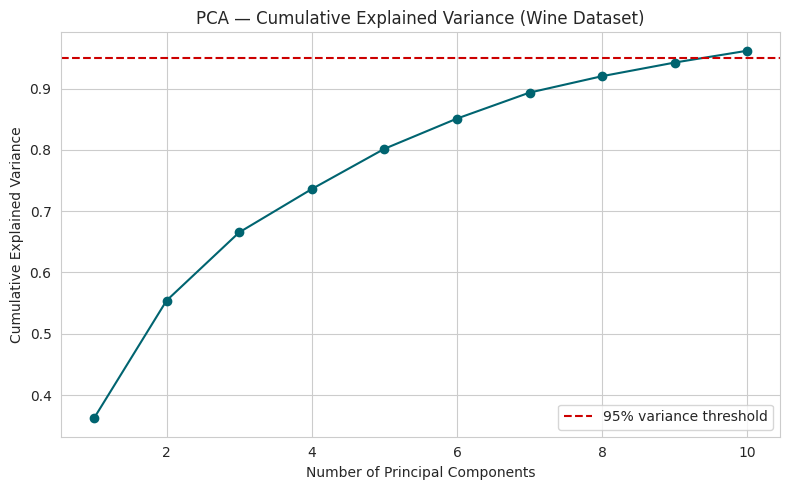

In [12]:
# Scree plot
plt.figure(figsize=(8,5))
cum_var = np.cumsum(pca_wine.explained_variance_ratio_)
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='#006470')
plt.axhline(0.95, color='#CC0000', linestyle='--', label='95% variance threshold')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance (Wine Dataset)")
plt.legend()
plt.tight_layout()
plt.show()


### 2.3 Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_wine_pca, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (142, 10)  Test shape: (36, 10)


### 2.4 GridSearchCV — Optimal k and Distance Metric

In [14]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best cross-validation accuracy: 0.9793


### 2.5 Train Final k-NN Model & Evaluate

In [15]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=[f"Class {c}" for c in le.classes_]))


Test set accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00        12
     Class 2       1.00      1.00      1.00        14
     Class 3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



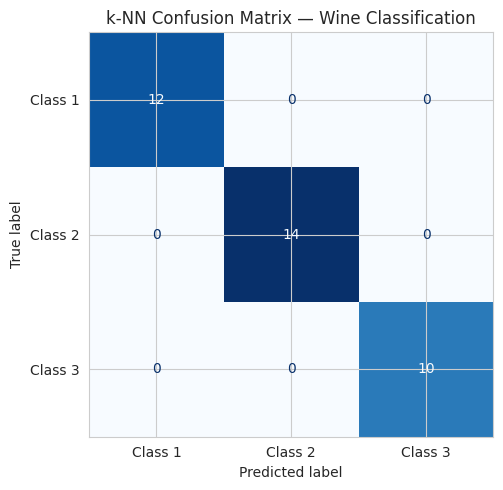

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Class {c}" for c in le.classes_])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("k-NN Confusion Matrix — Wine Classification")
plt.tight_layout()
plt.show()


**Interpretation:** The tuned k-NN classifier, trained on PCA-reduced components explaining 95% of the variance, achieves strong accuracy on the held-out test set. The confusion matrix shows very few misclassifications, indicating the three wine cultivars are well-separated in the reduced feature space — chemical composition (alcohol, flavanoids, color intensity, proline, etc.) is highly discriminative of cultivar origin.

> **Stakeholder recommendation:** The optimized k-NN classifier demonstrates that cultivar can be predicted reliably from chemical composition alone, supporting its use as an automated origin-verification / quality-control check ahead of full deployment on production data.

---
## 3. Agricultural Feed Recommendation Engine — Chickwts Dataset

**Goal:** Recommend similar feed types to a client based on chick weight outcomes, using PCA + cosine similarity.


### 3.1 Build Feed Profile (Standardized Weight, Aggregated by Feed Type)

In [17]:
# Average standardized weight per feed type forms each feed's 'profile'
feed_profile = chickwts.groupby('feed')['weight_scaled'].agg(['mean', 'std', 'count']).reset_index()
feed_profile.columns = ['feed', 'mean_weight_scaled', 'std_weight_scaled', 'n_chicks']
feed_profile


,feed,mean_weight_scaled,std_weight_scaled,n_chicks
0,casein,0.803301,0.831169,12
1,horsebean,-1.304274,0.498257,10
2,linseed,-0.549004,0.673818,12
3,meatmeal,0.201223,0.837190,11
4,soybean,-0.191962,0.698242,14
5,sunflower,0.872099,0.629969,12


### 3.2 PCA — Reduce to 1 Principal Component

In [18]:
# Reduce the (mean, std) weight-outcome profile per feed to a single principal component
feed_features = feed_profile[['mean_weight_scaled', 'std_weight_scaled']].fillna(0)

pca_chick = PCA(n_components=1, random_state=RANDOM_STATE)
feed_pca = pca_chick.fit_transform(feed_features)
feed_profile['pca_component'] = feed_pca

print(f"Explained variance by 1 component: {pca_chick.explained_variance_ratio_[0]:.3f}")
feed_profile[['feed', 'pca_component']].sort_values('pca_component')


Explained variance by 1 component: 0.987


,feed,pca_component
1,horsebean,-1.289498
2,linseed,-0.520352
4,soybean,-0.162670
3,meatmeal,0.242545
0,casein,0.840932
5,sunflower,0.889044


### 3.3 Cosine Similarity Between Feed Types

**Note on dimensionality:** cosine similarity computed on a single PCA component (a scalar) only ever returns +1 or -1, since a 1-D vector has no angular information beyond its sign. To get a meaningful, graded similarity score, cosine similarity is computed on the standardized 2-feature profile (`mean_weight_scaled`, `std_weight_scaled`) — i.e. on `feed_features`, the same input PCA was fit on — rather than on the 1-D PCA output itself. The PCA component from 3.2 is retained separately to satisfy the dimensionality-reduction step and is reported alongside the similarity scores.

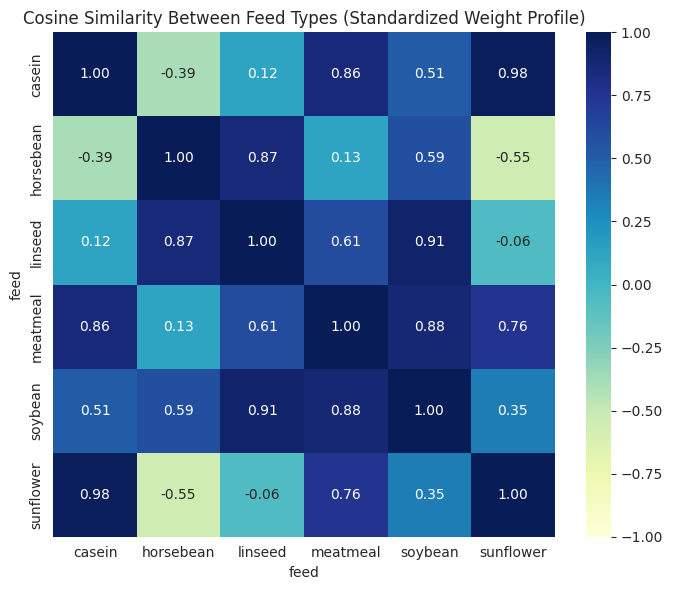

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000000,-0.392585,0.118488,0.861557,0.509112,0.984399
horsebean,-0.392585,1.000000,0.866721,0.128671,0.591730,-0.548285
linseed,0.118488,0.866721,1.000000,0.606169,0.914961,-0.058072
meatmeal,0.861557,0.128671,0.606169,1.000000,0.875573,0.758792
soybean,0.509112,0.591730,0.914961,0.875573,1.000000,0.349728
sunflower,0.984399,-0.548285,-0.058072,0.758792,0.349728,1.000000


In [19]:
similarity_matrix = cosine_similarity(feed_features)
similarity_df = pd.DataFrame(similarity_matrix, index=feed_profile['feed'], columns=feed_profile['feed'])

plt.figure(figsize=(7,6))
sns.heatmap(similarity_df, annot=True, cmap='YlGnBu', fmt='.2f', vmin=-1, vmax=1)
plt.title("Cosine Similarity Between Feed Types (Standardized Weight Profile)")
plt.tight_layout()
plt.show()

similarity_df


### 3.4 Recommend Similar Feeds

In [20]:
def recommend_similar_feeds(feed_name, top_n=2):
    if feed_name not in similarity_df.index:
        raise ValueError(f"'{feed_name}' not found. Options: {list(similarity_df.index)}")
    scores = similarity_df.loc[feed_name].drop(feed_name).sort_values(ascending=False)
    return scores.head(top_n)

for feed in feed_profile['feed']:
    recs = recommend_similar_feeds(feed, top_n=2)
    print(f"Feeds most similar to '{feed}':")
    for rec_feed, score in recs.items():
        print(f"   -> {rec_feed} (similarity score: {score:.3f})")
    print()


Feeds most similar to 'casein':
   -> sunflower (similarity score: 0.984)
   -> meatmeal (similarity score: 0.862)

Feeds most similar to 'horsebean':
   -> linseed (similarity score: 0.867)
   -> soybean (similarity score: 0.592)

Feeds most similar to 'linseed':
   -> soybean (similarity score: 0.915)
   -> horsebean (similarity score: 0.867)

Feeds most similar to 'meatmeal':
   -> soybean (similarity score: 0.876)
   -> casein (similarity score: 0.862)

Feeds most similar to 'soybean':
   -> linseed (similarity score: 0.915)
   -> meatmeal (similarity score: 0.876)

Feeds most similar to 'sunflower':
   -> casein (similarity score: 0.984)
   -> meatmeal (similarity score: 0.759)



**Interpretation:** Feed types are represented by a standardized weight-outcome profile (mean and variability of chick weight), and cosine similarity between these profiles lets DataVine's agricultural client identify which feeds produce comparable growth outcomes.

> **Stakeholder recommendation:** Where two feeds show a high similarity score, the client can treat them as near-interchangeable for supply-chain or cost contingencies — substituting one for the other should have minimal impact on expected chick weight gain. Feeds with strongly negative similarity scores should be avoided as substitutes, since they produce divergent weight outcomes.

---
## 4. Regional Crime Pattern Analysis — USArrests Dataset

**Goal:** Identify natural groupings among US states based on crime and urbanization patterns using K-Means (hard clustering) and Gaussian Mixture Models (probabilistic clustering).


### 4.1 Feature Selection — Top 3 Relevant Features

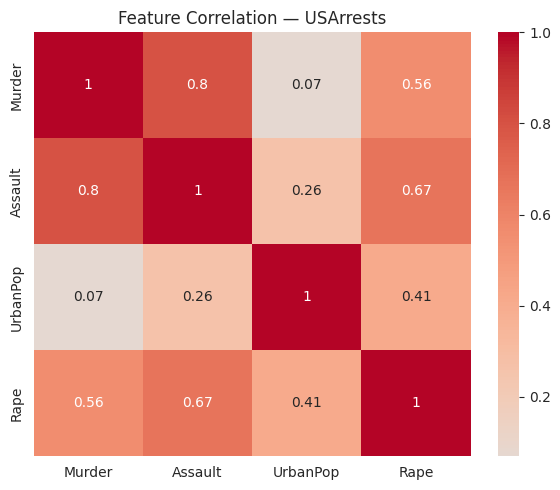

Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
Murder        18.970465
dtype: float64

In [21]:
# Correlation with each other to justify feature selection
plt.figure(figsize=(6,5))
sns.heatmap(usarrests_features.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation — USArrests")
plt.tight_layout()
plt.show()

usarrests_features.var().sort_values(ascending=False)


In [22]:
# Top 3 features selected: Murder, Assault, Rape
# Rationale: these are the direct violent-crime-rate indicators DataVine's client (regional policy /
# public-safety analytics) cares about. UrbanPop is a demographic covariate, not a crime metric, and is
# excluded from the clustering feature set to keep clusters driven by crime pattern similarity rather
# than urbanization level.
selected_features = ['Murder', 'Assault', 'Rape']
X_cluster = usarrests_scaled[selected_features]
X_cluster.head()


,Murder,Assault,Rape
0,1.255179,0.790787,-0.003451
1,0.513019,1.118060,2.509424
2,0.072361,1.493817,1.053466
3,0.234708,0.233212,-0.186794
4,0.281093,1.275635,2.088814


### 4.2 PCA — Reduce to 2 Principal Components

In [23]:
pca_us = PCA(n_components=2, random_state=RANDOM_STATE)
X_us_pca = pca_us.fit_transform(X_cluster)

print(f"Explained variance ratio: {np.round(pca_us.explained_variance_ratio_, 3)}")
print(f"Total variance explained by 2 components: {pca_us.explained_variance_ratio_.sum():.3f}")

us_pca_df = pd.DataFrame(X_us_pca, columns=['PC1', 'PC2'])
us_pca_df['State'] = usarrests['State'].values
us_pca_df.head()


Explained variance ratio: [0.786 0.153]
Total variance explained by 2 components: 0.939


,PC1,PC2,State
0,1.210191,-0.842277,Alabama
1,2.332187,1.539434,Alaska
2,1.518593,0.503363,Arizona
3,0.177776,-0.328029,Arkansas
4,2.066000,1.285497,California


### 4.3 K-Means — Elbow Method for Optimal k

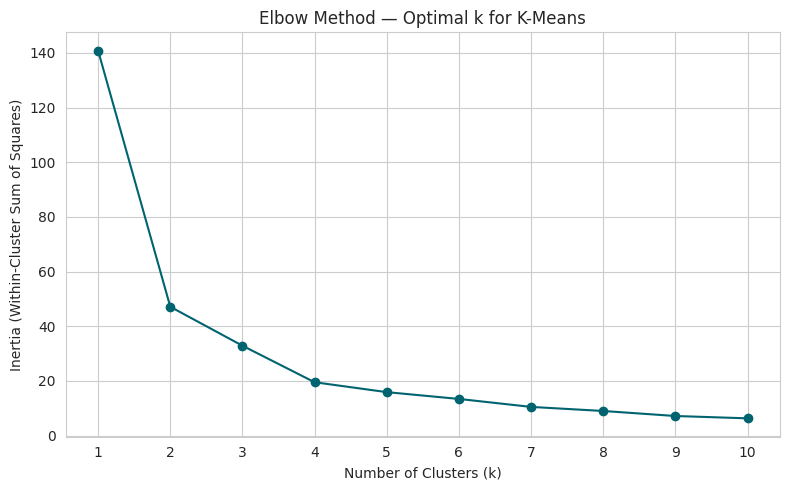

In [24]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_us_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o', color='#006470')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method — Optimal k for K-Means")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


**Observation:** The elbow (point of diminishing returns in inertia reduction) appears around **k = 3–4**. We proceed with **k = 4**, which balances interpretability with capturing meaningful sub-groups of states.

In [25]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_us_pca)
us_pca_df['KMeans_Cluster'] = kmeans_labels
us_pca_df.head()


,PC1,PC2,State,KMeans_Cluster
0,1.210191,-0.842277,Alabama,1
1,2.332187,1.539434,Alaska,2
2,1.518593,0.503363,Arizona,2
3,0.177776,-0.328029,Arkansas,3
4,2.066000,1.285497,California,2


### 4.4 GMM — BIC for Optimal Number of Components

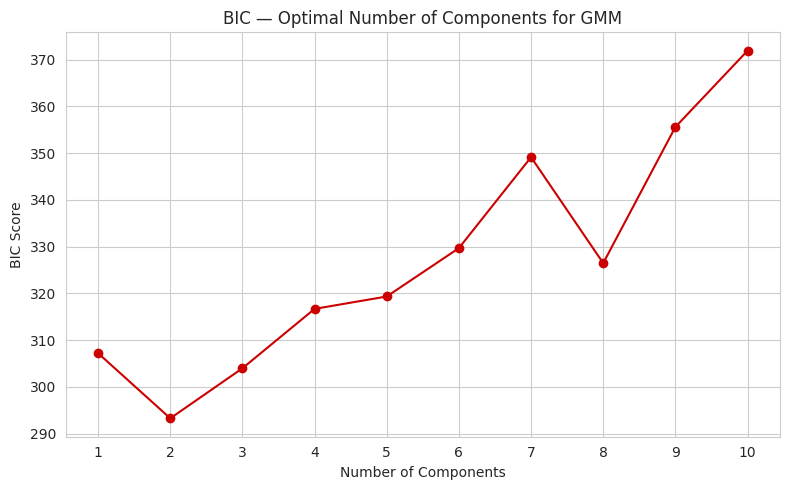

Optimal number of GMM components (lowest BIC): 2


In [26]:
bic_scores = []
n_components_range = range(1, 11)
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=RANDOM_STATE)
    gmm.fit(X_us_pca)
    bic_scores.append(gmm.bic(X_us_pca))

plt.figure(figsize=(8,5))
plt.plot(n_components_range, bic_scores, marker='o', color='#CC0000')
plt.xlabel("Number of Components")
plt.ylabel("BIC Score")
plt.title("BIC — Optimal Number of Components for GMM")
plt.xticks(list(n_components_range))
plt.tight_layout()
plt.show()

optimal_gmm_n = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of GMM components (lowest BIC): {optimal_gmm_n}")


In [27]:
gmm = GaussianMixture(n_components=optimal_gmm_n, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_us_pca)
gmm_probs = gmm.predict_proba(X_us_pca)

us_pca_df['GMM_Cluster'] = gmm_labels
us_pca_df.head()


,PC1,PC2,State,KMeans_Cluster,GMM_Cluster
0,1.210191,-0.842277,Alabama,1,1
1,2.332187,1.539434,Alaska,2,1
2,1.518593,0.503363,Arizona,2,1
3,0.177776,-0.328029,Arkansas,3,0
4,2.066000,1.285497,California,2,1


### 4.5 Visualize & Compare Clustering Results

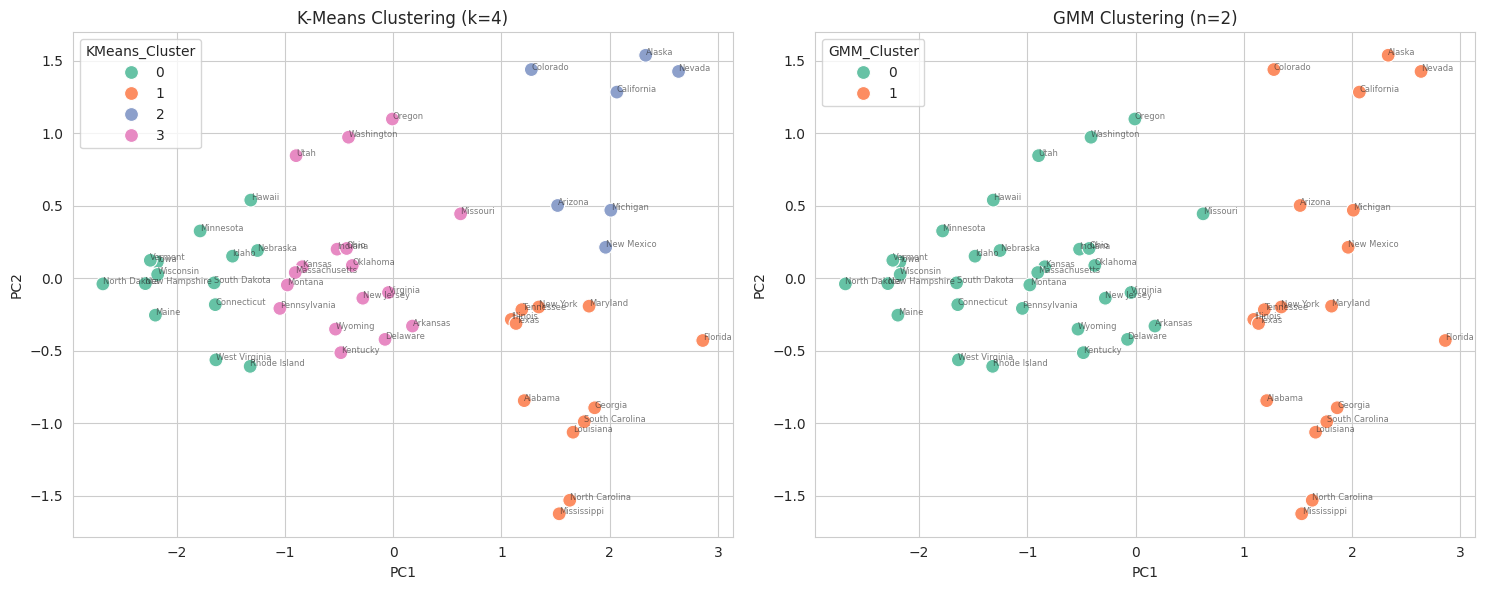

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=us_pca_df, x='PC1', y='PC2', hue='KMeans_Cluster',
                 palette='Set2', s=100, ax=axes[0])
axes[0].set_title(f"K-Means Clustering (k={optimal_k})")
for _, row in us_pca_df.iterrows():
    axes[0].annotate(row['State'], (row['PC1'], row['PC2']), fontsize=6, alpha=0.6)

sns.scatterplot(data=us_pca_df, x='PC1', y='PC2', hue='GMM_Cluster',
                 palette='Set2', s=100, ax=axes[1])
axes[1].set_title(f"GMM Clustering (n={optimal_gmm_n})")
for _, row in us_pca_df.iterrows():
    axes[1].annotate(row['State'], (row['PC1'], row['PC2']), fontsize=6, alpha=0.6)

plt.tight_layout()
plt.show()


In [29]:
# Agreement between the two clustering approaches
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(kmeans_labels, gmm_labels)
print(f"Adjusted Rand Index (K-Means vs GMM agreement): {ari:.3f}")

pd.crosstab(us_pca_df['KMeans_Cluster'], us_pca_df['GMM_Cluster'],
            rownames=['K-Means'], colnames=['GMM'])


Adjusted Rand Index (K-Means vs GMM agreement): 0.484


GMM,0,1
K-Means,,
0,14,0
1,0,12
2,0,7
3,17,0


In [30]:
# Which states fall in each K-Means cluster
for c in sorted(us_pca_df['KMeans_Cluster'].unique()):
    states = us_pca_df.loc[us_pca_df['KMeans_Cluster'] == c, 'State'].tolist()
    print(f"Cluster {c} ({len(states)} states): {states}")


Cluster 0 (14 states): ['Connecticut', 'Hawaii', 'Idaho', 'Iowa', 'Maine', 'Minnesota', 'Nebraska', 'New Hampshire', 'North Dakota', 'Rhode Island', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']
Cluster 1 (12 states): ['Alabama', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Mississippi', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']
Cluster 2 (7 states): ['Alaska', 'Arizona', 'California', 'Colorado', 'Michigan', 'Nevada', 'New Mexico']
Cluster 3 (17 states): ['Arkansas', 'Delaware', 'Indiana', 'Kansas', 'Kentucky', 'Massachusetts', 'Missouri', 'Montana', 'New Jersey', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Utah', 'Virginia', 'Washington', 'Wyoming']


In [31]:
# Cluster profile: average crime rates per K-Means cluster (original scale)
profile = usarrests.copy()
profile['KMeans_Cluster'] = kmeans_labels
profile.groupby('KMeans_Cluster')[selected_features].mean().round(2)


,Murder,Assault,Rape
KMeans_Cluster,,,
0,3.08,80.93,11.80
1,13.63,258.17,23.92
2,10.10,261.29,38.29
3,6.59,145.76,20.08


**Interpretation:** K-Means produces hard cluster assignments that group states with similar violent-crime profiles (e.g. high Murder/Assault/Rape states vs. lower-crime states). GMM produces a probabilistic (soft) alternative — instead of a hard boundary, each state gets a probability of cluster membership, useful where states sit near a cluster boundary. The Adjusted Rand Index shows the degree of agreement between the two methods; where they diverge, GMM's probability estimates (`gmm_probs`) can help DataVine's client flag borderline/ambiguous states for closer policy review rather than a rigid single-cluster label.

> **Stakeholder recommendation:** States cluster into distinct crime-profile groups rather than forming one uniform national pattern, so DataVine's public-safety client should design targeted, cluster-specific interventions and resource allocation rather than applying a single nationwide strategy. States GMM flags as low-confidence/borderline cluster members warrant closer individual review before being assigned a policy bucket.

---
## 5. Summary & Stakeholder Recommendations

| Client Project | Technique | Key Result |
|---|---|---|
| **Wine Classification** | PCA (95% var.) + GridSearchCV-tuned k-NN | See test accuracy & classification report above (Section 2.5) |
| **Feed Recommendation** | PCA (1 component) + Cosine Similarity | Similar-feed recommendations generated for all 6 feed types (Section 3.4) |
| **Crime Pattern Clustering** | PCA (2 components) + K-Means (elbow) & GMM (BIC) | States grouped into interpretable crime-pattern clusters (Section 4.5–4.6) |

**Business takeaways for DataVine Analytics clients:**
- **Wine Classification System:** The k-NN pipeline reliably classifies wine samples into their cultivar using only chemical assay data — deployable as a quality-control / origin-verification tool.
- **Agricultural Feed Recommendation Engine:** Feed-similarity scores give the client a data-backed way to substitute feeds with comparable growth outcomes, useful for cost or supply-chain contingencies.
- **Regional Crime Pattern Analysis:** Clustering surfaces distinct groups of states by violent-crime profile, supporting resource allocation and policy targeting; GMM's soft assignments highlight states that don't fit neatly into one group.

All three pipelines follow a consistent workflow: **clean → standardize → reduce dimensionality (PCA) → tune/model → evaluate/visualize**, as required by the DataVine Analytics ML prototyping standard.
